In [2]:
import os

print(os.getcwd())

c:\Users\siddh\OneDrive\Documents\.vscode\bluestock_mf_capstone


In [3]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

.\data\processed\01_fund_master_clean.csv
.\data\processed\02_nav_history_clean.csv
.\data\processed\03_aum_clean.csv
.\data\processed\04_sip_clean.csv
.\data\processed\05_category_inflows_clean.csv
.\data\processed\06_folio_clean.csv
.\data\processed\07_scheme_performance_clean.csv
.\data\processed\08_transactions_clean.csv
.\data\processed\09_portfolio_clean.csv
.\data\processed\10_benchmark_clean.csv
.\data\processed\alpha_beta.csv
.\data\processed\cagr_report.csv
.\data\processed\dim_date.csv
.\data\processed\dim_fund_with_metrics.csv
.\data\processed\fact_aum_quarterly.csv
.\data\processed\fact_benchmark_daily.csv
.\data\processed\fact_category_inflows_clean.csv
.\data\processed\fact_nav_daily.csv
.\data\processed\fact_sip_monthly.csv
.\data\processed\fact_transactions_enriched.csv
.\data\processed\fund_scorecard.csv
.\data\processed\kpi_summary.csv
.\data\processed\max_drawdown.csv
.\data\processed\returns_computed.csv
.\data\processed\sharpe_values.csv
.\data\processed\sortino_v

In [4]:
import pandas as pd

returns = pd.read_csv("./data/processed/returns_computed.csv")
sharpe = pd.read_csv("./data/processed/sharpe_values.csv")
transactions = pd.read_csv("./data/processed/fact_transactions_enriched.csv")
fund_metrics = pd.read_csv("./data/processed/dim_fund_with_metrics.csv")
portfolio = pd.read_csv("./data/processed/09_portfolio_clean.csv")

In [5]:
for name, df in {
    "returns": returns,
    "sharpe": sharpe,
    "transactions": transactions,
    "fund_metrics": fund_metrics,
    "portfolio": portfolio
}.items():
    print("\n" + name)
    print(df.columns.tolist())


returns
['amfi_code', 'date', 'nav', 'daily_return_pct', 'daily_return']

sharpe
['amfi_code', 'scheme_name', 'sharpe_ratio']

transactions
['investor_id', 'transaction_date', 'transaction_date_id', 'year', 'month', 'year_month', 'amfi_code', 'transaction_type', 'amount_inr', 'amount_crore', 'state', 'city', 'city_tier', 'state_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

fund_metrics
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'expense_ratio_pct', 'launch_date', 'benchmark', 'risk_category', 'cagr_1yr_pct', 'cagr_3yr_pct', 'cagr_5yr_pct', 'sharpe_ratio', 'sortino_ratio', 'alpha', 'beta', 'r_squared', 'max_drawdown_pct', 'composite_score', 'aum_crore']

portfolio
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [6]:
import pandas as pd

returns = pd.read_csv(
    "./data/processed/returns_computed.csv"
)

var_results = []

for fund, grp in returns.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    var_95 = r.quantile(0.05)

    cvar_95 = r[r <= var_95].mean()

    var_results.append({
        "amfi_code": fund,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_df = pd.DataFrame(var_results)

In [7]:
var_df = var_df.merge(
    fund_metrics[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [8]:
var_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

In [10]:
top5 = (
    sharpe
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

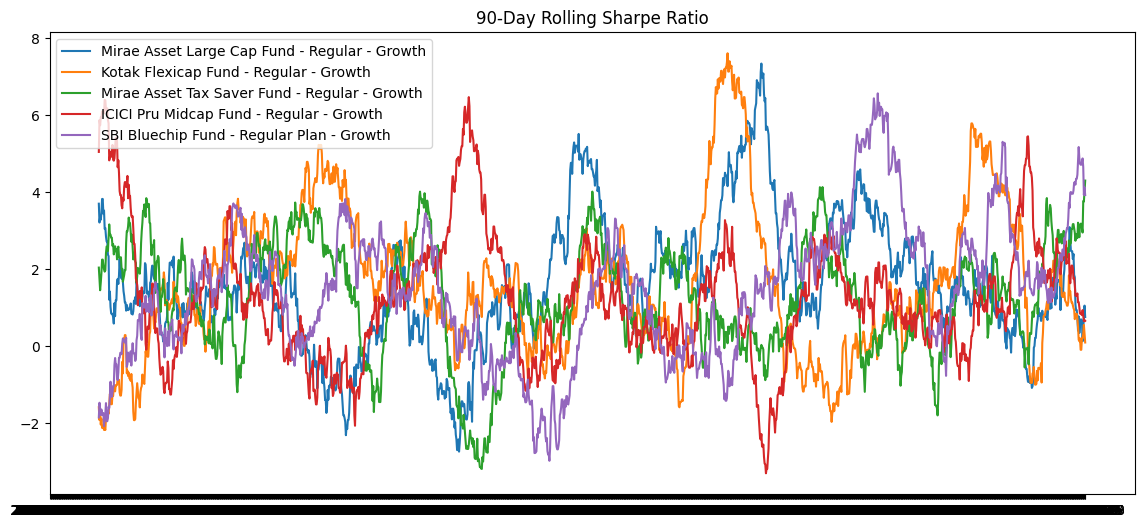

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for fund in top5["amfi_code"]:

    temp = returns[
        returns["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    name = (
        top5.loc[
            top5["amfi_code"] == fund,
            "scheme_name"
        ]
        .iloc[0]
    )

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=name
    )

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [14]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

cohort = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .dt.year
)

transactions["cohort_year"] = (
    transactions["investor_id"]
    .map(cohort)
)

In [15]:
cohort_stats = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

In [16]:
top_fund = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="cnt")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year","cnt"],
        ascending=False
    )
    .drop_duplicates(
        "cohort_year"
    )
)

In [17]:
counts = (
    transactions
    .groupby("investor_id")
    .size()
)

eligible = counts[
    counts >= 6
].index

In [18]:
risk_list = []

for inv in eligible:

    temp = (
        transactions[
            transactions["investor_id"] == inv
        ]
        .sort_values(
            "transaction_date"
        )
    )

    gap = (
        temp["transaction_date"]
        .diff()
        .dt.days
        .mean()
    )

    risk_list.append({
        "investor_id": inv,
        "avg_gap": gap,
        "at_risk": gap > 35
    })

sip_risk = pd.DataFrame(
    risk_list
)

In [19]:
continuity_rate = (
    (~sip_risk["at_risk"])
    .mean()
    * 100
)

In [20]:
def recommend_funds(risk_level):

    rec = (
        fund_metrics[
            fund_metrics[
                "risk_category"
            ] == risk_level
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return rec[
        [
            "scheme_name",
            "risk_category",
            "sharpe_ratio"
        ]
    ]

In [21]:
print(
    recommend_funds(
        "Moderate"
    )
)

                                       scheme_name risk_category  sharpe_ratio
34   Mirae Asset Large Cap Fund - Regular - Growth      Moderate        1.2336
0        SBI Bluechip Fund - Regular Plan - Growth      Moderate        0.9844
15  Nippon India Large Cap Fund - Regular - Growth      Moderate        0.8653


In [22]:
portfolio[
    "weight_decimal"
] = (
    portfolio["weight_pct"]
    / 100
)

hhi = (
    portfolio
    .groupby("amfi_code")
    ["weight_decimal"]
    .apply(
        lambda x:
        (x**2).sum()
    )
    .reset_index(
        name="HHI"
    )
)

In [23]:
hhi = hhi.merge(
    fund_metrics[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

In [26]:
import os

files = [
    "var_cvar_report.csv",
    "rolling_sharpe_chart.png",
    "recommender.py"
]

for f in files:
    print(f, "✓" if os.path.exists(f) else "✗")

var_cvar_report.csv ✓
rolling_sharpe_chart.png ✓
recommender.py ✓


In [25]:
with open("recommender.py", "w") as f:
    f.write("""
def recommend_funds(risk_level, fund_metrics):
    rec = (
        fund_metrics[
            fund_metrics["risk_category"] == risk_level
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )
    return rec[
        ["scheme_name","risk_category","sharpe_ratio"]
    ]
""")